# LSTM model with limited input

**Directly predict *near-term* volatility (only) from historical return and volatility.**

Author: Pete King

This notebook uses financial data to train a univariate Long Short-Term Memory (LSTM) model to predict ***near-term*** **volatility** for a single ETF representing a market sector, using only the ETF's historical return and volatility as input.

The purpose of this notebook is to establish a baseline for an LSTM's ability to predict future volatility in a near-term outlook using limited input.  Subsequent LSTM models will incorporate additional features derived from macroeconomic data and market sentiment indicies.  We will compare performance of the models with limited vs. expanded input to asses the degree to which additional features help or hinder a model's ability to predict future financial performance.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 10  # No. observations in each input sequence to LSTM
BATCH_SIZE = 21  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

We keep only return and historical volatility features for the asset in question.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols = [TICKER + '_ret-h', TICKER + '_vol-h']
label_col = [TICKER + '_vol_target']
train_df[data_cols + label_col].head(SEQUENCE_LENGTH)

,SPY_ret-h,SPY_vol-h,SPY_vol_target
date,,,
2015-10-15,0.005650,0.007701,0.008268
2015-10-16,0.009590,0.007959,0.009382
2015-10-19,0.009138,0.007951,0.009444
2015-10-20,0.014181,0.007453,0.009466
2015-10-21,0.012764,0.007660,0.010365
2015-10-22,0.014279,0.008268,0.007168
2015-10-23,0.020644,0.009382,0.005598
2015-10-26,0.017692,0.009444,0.007602
2015-10-27,0.017037,0.009466,0.007663


In [3]:
val_df[data_cols + label_col]

,SPY_ret-h,SPY_vol-h,SPY_vol_target
date,,,
2023-01-03,-0.005473,0.010149,0.012281
2023-01-04,0.006169,0.010569,0.013061
2023-01-05,0.007195,0.010334,0.012119
2023-01-06,0.012028,0.012081,0.006860
2023-01-09,0.014099,0.012026,0.006905
...,...,...,...
2024-08-26,0.002106,0.006228,0.010568
2024-08-27,0.005106,0.006215,0.010590
2024-08-28,-0.004147,0.006562,0.010323


## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

We use a custom Dataset for time series data.  The Dataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

Our goal is to predict future volatility, but what remains unknown is how far into the future we should try to predict.  In this investigation, we will vary the size of the future-looking window for volatility and examine the empirical results.

### Create Datasets and DataLoaders

For the initial investigation, we try to predict the *current day's volatility* using past observations.

*Note: PyTorch LSTM models require input to use datatype 'np.float32'*

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([10, 2])
Shape of first training label: torch.Size([1])


In [6]:
print(X_0)

tensor([[0.0056, 0.0077],
        [0.0096, 0.0080],
        [0.0091, 0.0080],
        [0.0142, 0.0075],
        [0.0128, 0.0077],
        [0.0143, 0.0083],
        [0.0206, 0.0094],
        [0.0177, 0.0094],
        [0.0170, 0.0095],
        [0.0346, 0.0104]])


In [7]:
print(y_0)

tensor([0.0059])


In [8]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([21, 10, 2])
Shape of first batch of labels: torch.Size([21, 1])


### Instantiate and train LSTM model

An important tunable hyperparameter for the LSTM is the size of the hidden layer.  A larger number of neurons will increase model complexity and could lead to overfitting, while too few neurons would increase the model's bias.  Considering the small number of input features, we use a relatively small hidden layer size.

Sequence length is another important hyperparameter.  We chose a sequence length of 21 to give our model one month (21 business days) worth of data, which should allow the model to learn recent trends in returns and volatility and perhaps learn relationships like, "several days of high returns leads to a period of high volatility," or "a spike in volatility tends to gradually decline over time towards the original baseline."

The ability of the LSTM to treat successive timestamps a dependent variables is a huge advantage over the Ridge and GBR models, which assume that all observations are independent of each other.

In [9]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [10]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [11]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(2, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


#### Loss function and Optimizer

The loss function and optimizer represent other hyperparameters we can tune for the LSTM model.  In undocumented tests, we explored the mean squared error loss function (MSELoss) and the root mean squared propagation (RMSprop) optimizer, but found the best results with the combinations below.

In [12]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [13]:
# Train and evaluate model
epochs = 1000
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 100 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 1000 epochs...
Epoch 100
Training loss:   0.0024541420862078667
Validation loss: 0.002940219594165683
Epoch 200
Training loss:   0.0016046920791268349
Validation loss: 0.0027615921571850777
Epoch 300
Training loss:   0.00045517925173044205
Validation loss: 0.0026948004961013794
Epoch 400
Training loss:   0.00011914316564798355
Validation loss: 0.0030212895944714546
Epoch 500
Training loss:   0.0006811199709773064
Validation loss: 0.003217153949663043
Epoch 600
Training loss:   0.0008288761600852013
Validation loss: 0.002843386959284544
Epoch 700
Training loss:   0.0007936665788292885
Validation loss: 0.003344406606629491
Epoch 800
Training loss:   0.0010339431464672089
Validation loss: 0.003309115767478943
Epoch 900
Training loss:   0.00027621258050203323
Validation loss: 0.0029999627731740475
Epoch 1000
Training loss:   0.00022010225802659988
Validation loss: 0.0031289237085729837


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


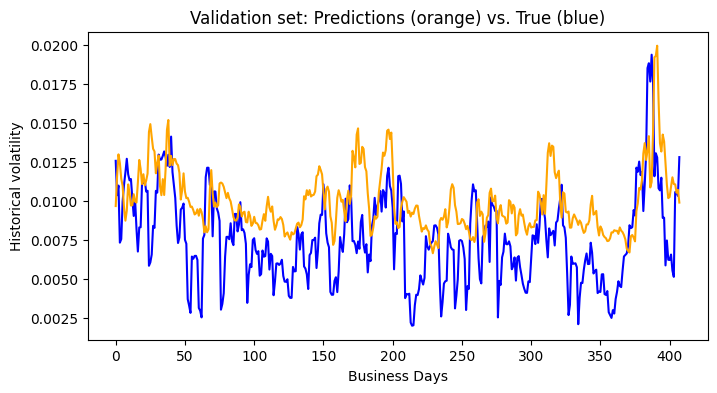

In [14]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')

In [15]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds))}')

R2: -0.5292822122573853
MAE: 0.0029885072726756334
RMSE: 0.003551672212779522
MSE: 1.2614375009434298e-05
